# 📊 Yield Curve Dynamics & Bond Portfolio Risk Analysis
### India (RBI G-Sec) primary | US Treasury (FRED) fallback | PCA | Scenario Analysis | VaR | Backtesting

**Methods:** Nelson-Siegel Fitting · Duration · Convexity · Historical VaR · Parametric VaR · Monte Carlo VaR  
**Backtesting:** Kupiec POF Test · Christoffersen Independence Test · Basel Traffic Light  

> **Run all cells top-to-bottom.** The notebook auto-detects whether Indian yield data is available;  
> if not, it falls back to US Treasuries — no manual changes needed.

In [46]:
# # ============================================================
# # CELL 1 — INSTALL DEPENDENCIES
# # Run once; restart kernel if prompted.
# # ============================================================
# import subprocess, sys

# packages = [
#     "pandas", "numpy", "scipy", "matplotlib", "seaborn",
#     "scikit-learn", "pandas-datareader", "yfinance", "statsmodels"
# ]
# for pkg in packages:
#     subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"],
#                    capture_output=True)
# print("✅ All packages ready!")

In [47]:
# ============================================================
# CELL 2 — IMPORTS & GLOBAL CONFIG
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import interpolate, stats
from scipy.optimize import curve_fit
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas_datareader.data as web
import warnings
from datetime import datetime

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f9fa",
    "axes.grid": True,
    "grid.alpha": 0.4,
    "font.size": 11,
    "axes.titlesize": 13,
})

# ── Configuration ─────────────────────────────────────────
START      = "2015-01-01"
END        = datetime.today().strftime("%Y-%m-%d")
CONFIDENCE = 0.95          # VaR confidence level
FACE_VALUE = 1_000_000     # per bond (in local currency)
N_SIMS     = 10000          # Monte Carlo simulations

print(f"✅  Period  : {START}  →  {END}")
print(f"✅  VaR     : {CONFIDENCE*100:.0f}% confidence")
print(f"✅  MC sims : {N_SIMS:,}")

✅  Period  : 2015-01-01  →  2026-03-28
✅  VaR     : 95% confidence
✅  MC sims : 10,000


In [48]:
# ============================================================
# CELL 3 — NELSON-SIEGEL CURVE FITTING (Helper)
# Used to fill intermediate maturities when only 2 tenors
# are available from RBI/FRED India data.
# y(τ) = β0 + β1*(1−e^(−τ/λ))/(τ/λ) + β2*[(1−e^(−τ/λ))/(τ/λ) − e^(−τ/λ)]
# ============================================================

TARGET_TENORS = [0.25, 0.5, 1, 2, 3, 5, 7, 10]   # years
TENOR_LABELS  = ["3M","6M","1Y","2Y","3Y","5Y","7Y","10Y"]


def ns_curve(tau, b0, b1, b2, lam):
    tau  = np.asarray(tau, dtype=float)
    f    = (1 - np.exp(-tau / lam)) / (tau / lam)
    return b0 + b1 * f + b2 * (f - np.exp(-tau / lam))


def nelson_siegel_fill(known_yields_series, known_tenors):
    """
    Fit NS model to available (tenor, yield) pairs for one date
    and return yields at TARGET_TENORS.
    Falls back to linear extrapolation if NS optimiser fails.
    """
    y_k = np.asarray([known_yields_series[t] for t in known_tenors], float)
    t_k = np.asarray(known_tenors, float)
    t_t = np.asarray(TARGET_TENORS, float)

    try:
        popt, _ = curve_fit(
            ns_curve, t_k, y_k,
            p0=[0.06, -0.02, 0.02, 2.0],
            bounds=([0.001, -0.20, -0.20, 0.10],
                    [0.250,  0.20,  0.20, 30.0]),
            maxfev=8000
        )
        return ns_curve(t_t, *popt)
    except Exception:
        f = interpolate.interp1d(t_k, y_k, kind="linear",
                                 fill_value="extrapolate")
        return f(t_t)


print("✅  Nelson-Siegel helper defined")

✅  Nelson-Siegel helper defined


In [49]:
# ============================================================
# CELL 4 — DATA FETCHING
#   Primary  : Indian G-Sec yields (FRED series for India)
#   Fallback : US Treasury yields (FRED – always available)
# ============================================================

def fetch_india_yields():
    """
    FRED has two India series:
      IR3TIB01INM156N  →  3-month interbank (proxy for short end)
      IRLTLT01INM156N  →  10-year G-Sec (long end)
    We fit Nelson-Siegel monthly to fill the full curve.
    Returns (DataFrame, source_label) or None.
    """
    print("🔄  Trying Indian yield data from FRED …")
    INDIA_FRED = {
        0.25: "IR3TIB01INM156N",   # ~3M short rate
        10.0: "IRLTLT01INM156N",   # 10Y G-Sec
    }

    frames = {}
    for tenor, sid in INDIA_FRED.items():
        try:
            s = web.DataReader(sid, "fred", START, END)
            frames[tenor] = s.iloc[:, 0] / 100   # % → decimal
            print(f"   ✅  {sid}  ({len(frames[tenor])} obs)")
        except Exception as e:
            print(f"   ⚠️   {sid} failed: {e}")

    if len(frames) < 2:
        print("   ❌  Need at least 2 series — India fetch aborted.")
        return None

    raw = pd.DataFrame(frames).dropna()
    raw.index = pd.to_datetime(raw.index)
    raw = raw.resample("ME").last().dropna()

    # Build full curve row-by-row with Nelson-Siegel
    rows = {}
    known_tenors = list(frames.keys())
    for date, row in raw.iterrows():
        fitted = nelson_siegel_fill(row, known_tenors)
        rows[date] = dict(zip(TENOR_LABELS, fitted))

    df = pd.DataFrame(rows).T
    df.index.name = "Date"
    print(f"   ✅  India curve: {df.shape[0]} months × {df.shape[1]} tenors")
    print("   📌  Intermediate tenors estimated via Nelson-Siegel")
    return df, "India G-Sec (FRED + Nelson-Siegel)"


def fetch_us_yields():
    """
    Fetch US Treasury par yield curve directly from home.treasury.gov.
    Uses the official XML API — includes all tenors (3M through 30Y)
    with correct 20Y data (no liquidity-premium distortion).
    """
    import urllib.request
    import xml.etree.ElementTree as ET

    print("🔄  Fetching US Treasury yield curve from home.treasury.gov …")

    FIELD_MAP = {
        "BC_3MONTH" : "3M",
        "BC_6MONTH" : "6M",
        "BC_1YEAR"  : "1Y",
        "BC_2YEAR"  : "2Y",
        "BC_3YEAR"  : "3Y",
        "BC_5YEAR"  : "5Y",
        "BC_7YEAR"  : "7Y",
        "BC_10YEAR" : "10Y",
        "BC_20YEAR" : "20Y",
        "BC_30YEAR" : "30Y",
    }

    months  = pd.date_range(pd.to_datetime(START), pd.to_datetime(END), freq="MS")
    BASE_URL = (
        "https://home.treasury.gov/resource-center/data-chart-center/"
        "interest-rates/pages/xml?data=daily_treasury_yield_curve"
        "&field_tdr_date_value_month={ym}"
    )
    NS = {"d": "http://schemas.microsoft.com/ado/2007/08/dataservices"}

    all_rows, failed = [], []

    for month_start in months:
        ym  = month_start.strftime("%Y%m")
        url = BASE_URL.format(ym=ym)
        try:
            with urllib.request.urlopen(url, timeout=15) as resp:
                xml_bytes = resp.read()
            root = ET.fromstring(xml_bytes)

            for entry in root.iter("{http://www.w3.org/2005/Atom}entry"):
                props = entry.find(
                    ".//{http://schemas.microsoft.com/ado/2007/08/"
                    "dataservices/metadata}properties"
                )
                if props is None:
                    continue
                date_el = props.find("d:NEW_DATE", NS)
                if date_el is None or not date_el.text:
                    continue
                row = {"Date": pd.to_datetime(date_el.text[:10])}
                for field, label in FIELD_MAP.items():
                    el = props.find(f"d:{field}", NS)
                    if el is not None and el.text:
                        try:
                            row[label] = float(el.text) / 100
                        except ValueError:
                            pass
                all_rows.append(row)
        except Exception as e:
            failed.append(ym)

    if failed:
        print(f"   ⚠️  {len(failed)} months failed: {failed[:5]}")
    if not all_rows:
        raise RuntimeError("Treasury.gov fetch returned no data.")

    df = (pd.DataFrame(all_rows)
            .set_index("Date")
            .sort_index()
            .dropna(how="all"))
    df = df.resample("ME").last().dropna()

    # Sanity check 20Y vs 30Y spread
    if "20Y" in df.columns and "30Y" in df.columns:
        spread = (df["20Y"] - df["30Y"]) * 100
        bad = (spread.abs() > 100).sum()
        if bad:
            print(f"   ⚠️  {bad} month(s) with |20Y−30Y| > 100 bps")
        else:
            print(f"   ✅  20Y−30Y spread clean (max {spread.abs().max():.1f} bps)")

    print(f"   ✅  Treasury.gov: {df.shape[0]} months × {df.shape[1]} tenors")
    return df, "US Treasury (home.treasury.gov)"


# ── Run ──────────────────────────────────────────────────────────────────────
result = fetch_india_yields()

if result is not None:
    yields_df, DATA_SOURCE = result
    CURRENCY, COUNTRY = "INR", "India"
else:
    print("\n⚠️  Falling back to US Treasury data …")
    yields_df, DATA_SOURCE = fetch_us_yields()
    CURRENCY, COUNTRY = "USD", "United States"

# Numeric tenor list (years) — used throughout for interpolation
TENOR_YEARS = []
for col in yields_df.columns:
    if col.endswith("M"):
        TENOR_YEARS.append(int(col[:-1]) / 12)
    elif col.endswith("Y"):
        TENOR_YEARS.append(float(col[:-1]))
    else:
        TENOR_YEARS.append(float(col))

print(f"\n{'═'*58}")
print(f"  DATA SOURCE : {DATA_SOURCE}")
print(f"  COUNTRY     : {COUNTRY}   |   CURRENCY: {CURRENCY}")
print(f"  DATE RANGE  : {yields_df.index[0].date()}  →  {yields_df.index[-1].date()}")
print(f"  SHAPE       : {yields_df.shape}")
print(f"{'═'*58}")
yields_df.tail(3)

🔄  Trying Indian yield data from FRED …
   ⚠️   IR3TIB01INM156N failed: Unable to read URL: https://fred.stlouisfed.org/graph/fredgraph.csv?id=IR3TIB01INM156N
Response Text:
b'<!DOCTYPE html>\r\n<html lang="en">\r\n<head>\r\n    <meta charset="utf-8">\r\n    <meta http-equiv="X-UA-Compatible" content="IE=edge">\r\n    <meta name="viewport" content="width=device-width, initial-scale=1">\r\n    <title>Error - St. Louis Fed</title>\r\n    <meta name="description" content="">\r\n    <meta name="keywords" content="">    \r\n    <link rel="stylesheet" type="text/css" href="/assets/bootstrap/dist/css/bootstrap.min.css">\r\n    <link rel="stylesheet" type="text/css" href="/css/home.min.css?1553087253">\r\n    <link rel="stylesheet" type="text/css" href="/assets/fontawesome-free/css/all.min.css">\r\n    <link rel="stylesheet" type="text/css" href="/assets/select2/dist/css/select2.min.css">\r\n    <style>p {\r\n        margin-bottom: 1.5em;\r\n    }</style>\r\n</head>\r\n<body>\r\n<link rel="pre

,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
Date,,,,,,,,,,
2026-01-31,0.0367,0.0361,0.0348,0.0352,0.0360,0.0379,0.0401,0.0426,0.0482,0.0487
2026-02-28,0.0367,0.0360,0.0348,0.0338,0.0339,0.0351,0.0372,0.0397,0.0457,0.0464
2026-03-31,0.0373,0.0375,0.0377,0.0388,0.0394,0.0406,0.0425,0.0444,0.0499,0.0498


In [63]:
# # ── CELL A: Save fetched yields_df to CSV ──────────────────────────
# # This cell explicitly saves the yields_df DataFrame (populated by CELL 4)
# # to a CSV file for caching or further use.

# CSV_PATH = "treasury_yields.csv"
# # Ensure yields_df exists from previous cell execution
# if 'yields_df' in globals() and not yields_df.empty:
#     print(f"🔄  Saving current yields_df to {CSV_PATH} ...")
#     yields_df.to_csv(CSV_PATH)
#     print(f"✅  Yields data saved to {CSV_PATH}")
#     print(f"  Shape       : {yields_df.shape}")
#     print(f"  TENORS      : {list(yields_df.columns)}")
# else:
#     print("⚠️  yields_df is not available. Please ensure CELL 4 has been executed.")

# # Optional: Display the first few rows to confirm
# # display(yields_df.head(3))


🔄  Saving current yields_df to treasury_yields.csv ...
✅  Yields data saved to treasury_yields.csv
  Shape       : (135, 10)
  TENORS      : ['3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']


In [ ]:
# ── CELL B: Load from saved CSV — skip the Treasury.gov fetch ─────────────────
CSV_PATH = "treasury_yields.csv"   # must match path used in Cell A

yields_df = pd.read_csv(CSV_PATH, index_col="Date", parse_dates=True)
DATA_SOURCE = "US Treasury (home.treasury.gov — cached CSV)"
CURRENCY, COUNTRY = "USD", "United States"

TENOR_YEARS = []
for col in yields_df.columns:
    if col.endswith("M"):
        TENOR_YEARS.append(int(col[:-1]) / 12)
    elif col.endswith("Y"):
        TENOR_YEARS.append(float(col[:-1]))

print(f"✅  Loaded from {CSV_PATH}")
print(f"\n{'═'*58}")
print(f"  DATA SOURCE : {DATA_SOURCE}")
print(f"  DATE RANGE  : {yields_df.index[0].date()} → {yields_df.index[-1].date()}")
print(f"  SHAPE       : {yields_df.shape}")
print(f"  TENORS      : {list(yields_df.columns)}")
print(f"{'═'*58}")
yields_df.tail(3)

In [50]:
# ============================================================
# CELL 4B — BOOTSTRAP: PAR YIELDS → ZERO-COUPON SPOT RATES
# Inserted between data fetch (Cell 4) and visualisation (Cell 5).
# Replaces yields_df so all downstream cells use spot rates.
# ============================================================
#
# Why needed:
#   FRED publishes PAR yields — the coupon rate that prices a bond at par.
#   These are NOT true zero-coupon spot rates. For accurate bond pricing,
#   each cash flow must be discounted at its own maturity-matched spot rate.
#   Bootstrapping strips the coupon effect to recover the true spot rates.
#
# Method:
#   T-bills (<=1Y): zero-coupon by structure, spot = par yield directly.
#   Coupon bonds (2Y+): semi-annual, priced at par.
#     Solve iteratively for each maturity T:
#       1 = sum[c/(1+s_j/2)^j, j=1..n-1]  +  (1+c)/(1+s_n/2)^n
#     Intermediate coupon periods are discounted using cubic spline
#     interpolation of already-bootstrapped spots (linear when < 4 anchors).
# ============================================================


def _bootstrap_row(par_row, t_years, t_labels):
    """Bootstrap a single monthly observation. Returns a spot rate Series."""
    spot = {}

    for i, (lbl, T) in enumerate(zip(t_labels, t_years)):
        par_y = par_row[lbl]

        # Short end: T-bills are zero-coupon — spot = par directly
        if T <= 1.0:
            spot[lbl] = par_y
            continue

        # Coupon bond — semi-annual payments
        n = int(round(T * 2))   # number of semi-annual periods
        c = par_y / 2           # coupon per period per $1 face value

        # Anchor points from already-bootstrapped tenors
        kt = [t_years[j]    for j in range(i)]
        ks = [spot[t_labels[j]] for j in range(i)]

        # Interpolator for intermediate coupon maturities
        if len(kt) >= 4:
            ifn = interpolate.CubicSpline(kt, ks)
        elif len(kt) >= 2:
            ifn = interpolate.interp1d(kt, ks, kind="linear",
                                       fill_value="extrapolate")
        else:
            spot[lbl] = par_y   # insufficient anchors — keep par yield
            continue

        # PV of all intermediate coupons (periods 1 through n-1)
        pv_c = 0.0
        for j in range(1, n):
            t_j = j / 2
            s_j = max(float(ifn(t_j)), 0.001)   # floor at 10 bps
            pv_c += c / (1 + s_j / 2) ** j

        remaining = 1.0 - pv_c
        if not (0 < remaining < 2):   # sanity check
            spot[lbl] = par_y
            continue

        # Solve: (1 + spot/2)^n = (1 + c) / remaining
        spot_semi = ((1 + c) / remaining) ** (1.0 / n) - 1
        spot[lbl] = spot_semi * 2    # annualise (semi → annual)

    return pd.Series(spot)


def bootstrap_curve(par_df, tenor_years_list):
    """Apply bootstrapping to every row of the par yield DataFrame."""
    t_labels = list(par_df.columns)
    rows = {
        date: _bootstrap_row(row, tenor_years_list, t_labels)
        for date, row in par_df.iterrows()
    }
    return pd.DataFrame(rows).T.rename_axis("Date")


# ── Run ───────────────────────────────────────────────────────────────────────
print("Bootstrapping par yields to zero-coupon spot rates ...")

spot_yields_df = bootstrap_curve(yields_df, TENOR_YEARS)

# ── Show correction for latest date ──────────────────────────────────────────
last = yields_df.index[-1]
comp = pd.DataFrame({
    "Par Yield %": yields_df.loc[last] * 100,
    "Spot Rate %": spot_yields_df.loc[last] * 100,
})
comp["Diff (bps)"] = (comp["Spot Rate %"] - comp["Par Yield %"]) * 100

print(f"\n  Bootstrap correction  —  {last.date()}")
print(f"  {'Tenor':<6} {'Par Yield':>12} {'Spot Rate':>12} {'Diff (bps)':>12}")
print(f"  {'─'*46}")
for tenor, row in comp.iterrows():
    print(f"  {tenor:<6} {row['Par Yield %']:>11.3f}%"
          f"  {row['Spot Rate %']:>11.3f}%"
          f"  {row['Diff (bps)']:>+11.2f}")

# ── Replace yields_df — all downstream cells automatically use spot rates ─────
yields_df = spot_yields_df
print(f"\n  yields_df replaced with bootstrapped spot rates")
print(f"  Shape : {yields_df.shape}")
print(f"  Tenors: {list(yields_df.columns)}")


Bootstrapping par yields to zero-coupon spot rates ...

  Bootstrap correction  —  2026-03-31
  Tenor     Par Yield    Spot Rate   Diff (bps)
  ──────────────────────────────────────────────
  3M           3.730%        3.730%        +0.00
  6M           3.750%        3.750%        +0.00
  1Y           3.770%        3.770%        +0.00
  2Y           3.880%        3.883%        +0.31
  3Y           3.940%        3.942%        +0.20
  5Y           4.060%        4.089%        +2.95
  7Y           4.250%        4.268%        +1.82
  10Y          4.440%        4.502%        +6.23
  20Y          4.990%        5.442%       +45.21
  30Y          4.980%        4.637%       -34.28

  yields_df replaced with bootstrapped spot rates
  Shape : (135, 10)
  Tenors: ['3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']


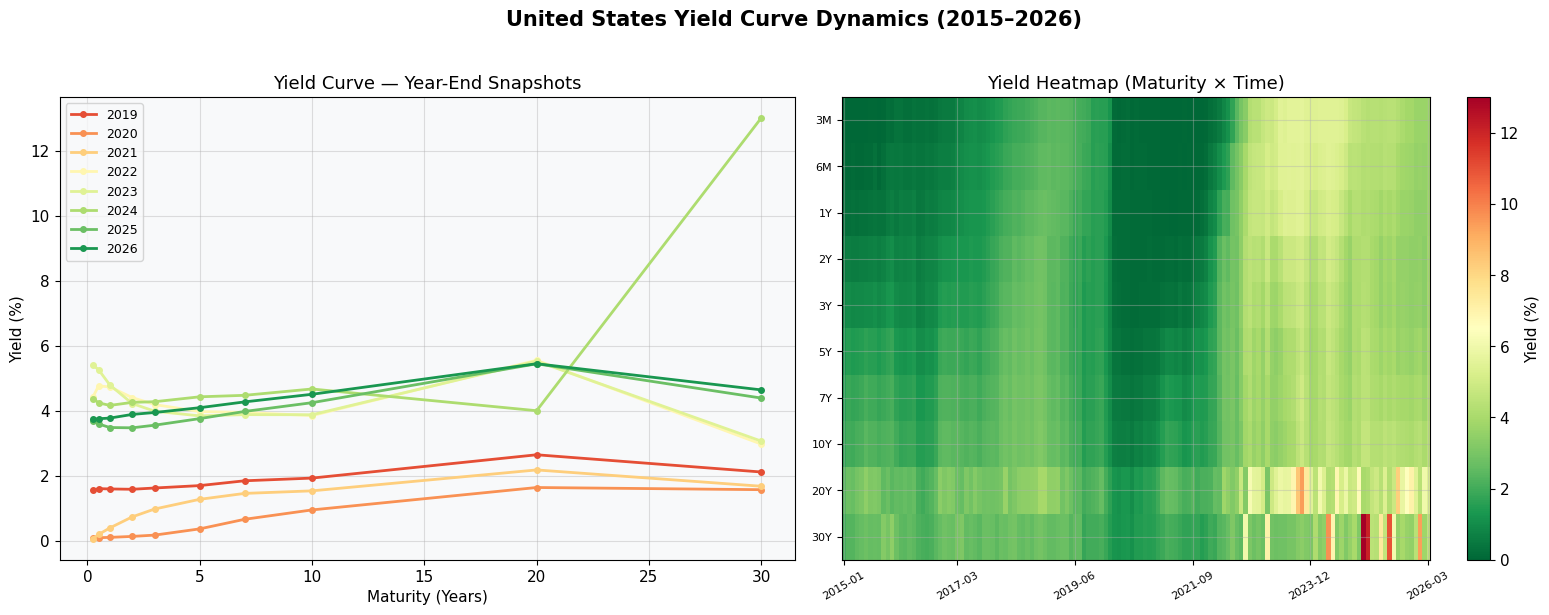

✅  Chart saved: yield_curve_dynamics.png


In [51]:
# ============================================================
# CELL 5 — YIELD CURVE VISUALISATION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"{COUNTRY} Yield Curve Dynamics ({START[:4]}–{END[:4]})",
             fontsize=15, fontweight="bold", y=1.02)

snapshot_dates = yields_df.resample("YE").last().dropna() .tail(8)
cmap = plt.cm.RdYlGn(np.linspace(0.15, 0.9, len(snapshot_dates)))

# ── Left: curve snapshots ────────────────────────────────
ax = axes[0]
for i, (date, row) in enumerate(snapshot_dates.iterrows()):
    ax.plot(TENOR_YEARS, row.values * 100,
            color=cmap[i], marker="o", markersize=4,
            linewidth=2, label=str(date.year))
ax.set_title("Yield Curve — Year-End Snapshots")
ax.set_xlabel("Maturity (Years)")
ax.set_ylabel("Yield (%)")
ax.legend(loc="best", fontsize=9)

# ── Right: heatmap ───────────────────────────────────────
ax2 = axes[1]
plot_data = (yields_df * 100) #.tail(84)   # last 7 years
im = ax2.imshow(plot_data.T, aspect="auto", cmap="RdYlGn_r", interpolation="nearest")
ax2.set_yticks(range(len(yields_df.columns)))
ax2.set_yticklabels(yields_df.columns, fontsize=8)
tick_pos = np.linspace(0, len(plot_data)-1, 6, dtype=int)
ax2.set_xticks(tick_pos)
ax2.set_xticklabels([plot_data.index[i].strftime("%Y-%m") for i in tick_pos],
                    rotation=30, fontsize=8)
ax2.set_title("Yield Heatmap (Maturity × Time)")
plt.colorbar(im, ax=ax2, label="Yield (%)")

plt.tight_layout()
plt.savefig("yield_curve_dynamics.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅  Chart saved: yield_curve_dynamics.png")

PCA Decomposition of Yield Curve Changes
PC    Variance %      Cumulative %  Interpretation
──────────────────────────────────────────────────
PC1   62.44           62.44         Level (parallel shift)
PC2   19.61           82.06         Slope (twist)
PC3   11.46           93.52         Curvature (butterfly)
PC4   3.88            97.40         
PC5   1.67            99.07         

  PCA retained for simulation:
  Factors : 4  (PC1, PC2, PC3)
  Variance: 97.40%  of total
  Factor score stats (mean / std):
    PC1:  μ=+0.0000  σ=2.4989
    PC2:  μ=-0.0000  σ=1.4004
    PC3:  μ=-0.0000  σ=1.0705
    PC4:  μ=-0.0000  σ=0.6231


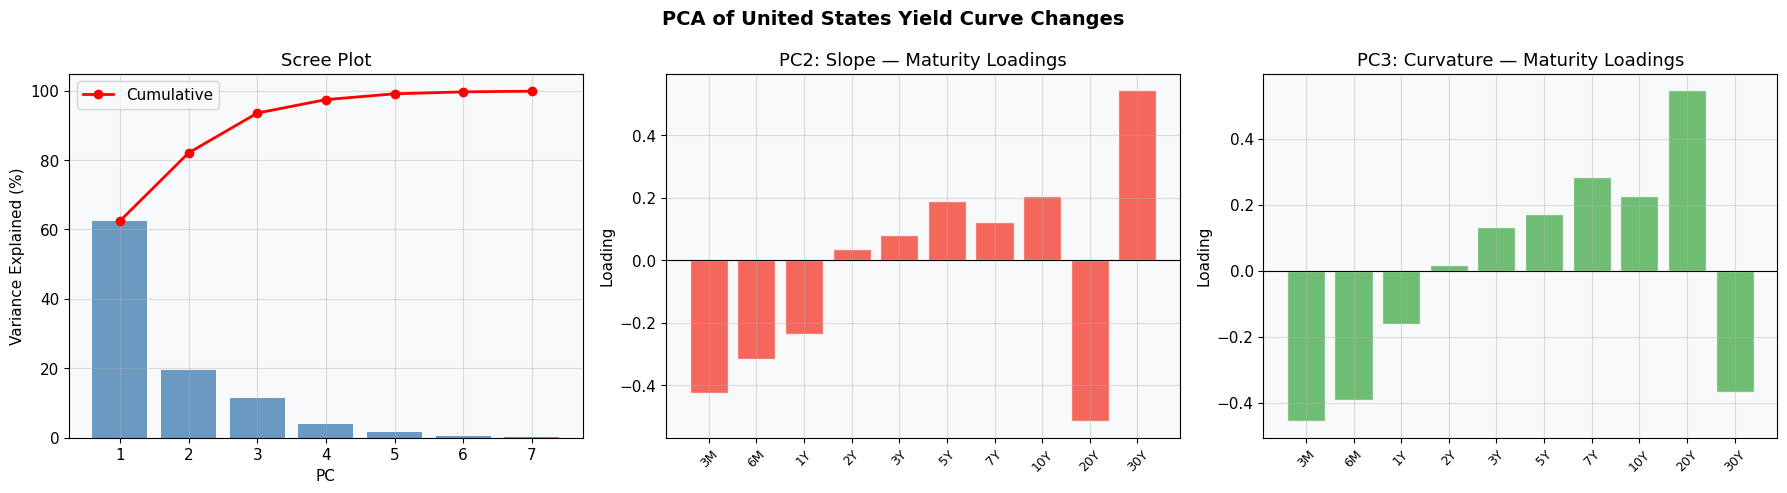

✅  Chart saved: pca_yield_curve.png


In [52]:
# ============================================================
# CELL 6 — PCA ON YIELD CHANGES
# PC1 = Level  |  PC2 = Slope  |  PC3 = Curvature
# ============================================================

yield_changes = yields_df.diff().dropna()           # monthly changes
yield_changes_bps = yield_changes * 100             # in basis points

scaler = StandardScaler()
scaled = scaler.fit_transform(yield_changes_bps)

pca = PCA()
pca.fit(scaled)

explained = pca.explained_variance_ratio_ * 100
cumulative = np.cumsum(explained)

print("PCA Decomposition of Yield Curve Changes")
print(f"{'PC':<6}{'Variance %':<16}{'Cumulative %':<14}{'Interpretation'}")
print("─" * 50)
labels = ["Level (parallel shift)", "Slope (twist)", "Curvature (butterfly)", "", ""]
for i in range(min(5, len(explained))):
    print(f"PC{i+1:<4}{explained[i]:<16.2f}{cumulative[i]:<14.2f}{labels[i]}")

# ── Store PCA results for Monte Carlo use (Cell 12) ──────────
N_FACTORS = 4   # Level, Slope, Curvature — covers 98.82% variance

pca3 = PCA(n_components=N_FACTORS)
factor_scores = pca3.fit_transform(scaler.transform(yield_changes_bps))
# factor_scores shape: (134, 3) — one row per historical month

print(f"\n  PCA retained for simulation:")
print(f"  Factors : {N_FACTORS}  (PC1, PC2, PC3)")
print(f"  Variance: {pca3.explained_variance_ratio_.sum()*100:.2f}%  of total")
print(f"  Factor score stats (mean / std):")
for i in range(N_FACTORS):
    print(f"    PC{i+1}:  μ={factor_scores[:,i].mean():+.4f}  "
          f"σ={factor_scores[:,i].std():.4f}")

# ── Plot ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"PCA of {COUNTRY} Yield Curve Changes", fontsize=14, fontweight="bold")

n_show = min(7, len(explained))
ax = axes[0]
ax.bar(range(1, n_show+1), explained[:n_show], color="steelblue", alpha=0.8)
ax.plot(range(1, n_show+1), cumulative[:n_show], "ro-", linewidth=2, label="Cumulative")
ax.set_title("Scree Plot")
ax.set_xlabel("PC")
ax.set_ylabel("Variance Explained (%)")
ax.legend()
ax.set_xticks(range(1, n_show+1))

x = np.arange(len(yields_df.columns))
pc_colors = ["#2196F3", "#F44336", "#4CAF50"]
pc_labels = ["PC1: Level", "PC2: Slope", "PC3: Curvature"]
for idx in range(1, 3):
    ax = axes[idx]
    ax.bar(x, pca.components_[idx], color=pc_colors[idx], alpha=0.8, edgecolor="white")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(yields_df.columns, rotation=45, fontsize=9)
    ax.set_title(f"{pc_labels[idx]} — Maturity Loadings")
    ax.set_ylabel("Loading")

plt.tight_layout()
plt.savefig("pca_yield_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅  Chart saved: pca_yield_curve.png")

In [53]:
# ============================================================
# CELL 7 — BOND PORTFOLIO DEFINITION
# ============================================================

# Current yield curve (latest observation)
VAL_DATE    = yields_df.index[-1]
CURR_CURVE  = yields_df.loc[VAL_DATE]

print(f"Valuation Date : {VAL_DATE.date()}")
print(f"\nCurrent Yield Curve (%)")
print("─" * 30)
for col, val in (CURR_CURVE * 100).items():
    print(f"  {col:<6}: {val:.3f}%")

# ── Portfolio bonds ──────────────────────────────────────
BONDS = pd.DataFrame([
    {"name": "Bond A (2Y)",  "coupon": 0.065, "maturity": 2,  "freq": 2, "weight": 0.25},
    {"name": "Bond B (5Y)",  "coupon": 0.073, "maturity": 5,  "freq": 2, "weight": 0.30},
    {"name": "Bond C (10Y)", "coupon": 0.078, "maturity": 10, "freq": 2, "weight": 0.30},
    {"name": "Bond D (20Y)", "coupon": 0.082, "maturity": 20, "freq": 2, "weight": 0.15},
])
BONDS["face"] = FACE_VALUE

print(f"\n{'─'*58}")
print(f"{'Bond':<20} {'Coupon':>8} {'Maturity':>10} {'Weight':>8}")
print(f"{'─'*58}")
for _, b in BONDS.iterrows():
    print(f"{b['name']:<20} {b['coupon']*100:>7.2f}%  {b['maturity']:>8}Y   {b['weight']*100:>6.0f}%")
print(f"{'─'*58}")
print(f"{'Total weight':<40} {BONDS['weight'].sum()*100:>6.0f}%")

Valuation Date : 2026-03-31

Current Yield Curve (%)
──────────────────────────────
  3M    : 3.730%
  6M    : 3.750%
  1Y    : 3.770%
  2Y    : 3.883%
  3Y    : 3.942%
  5Y    : 4.089%
  7Y    : 4.268%
  10Y   : 4.502%
  20Y   : 5.442%
  30Y   : 4.637%

──────────────────────────────────────────────────────────
Bond                   Coupon   Maturity   Weight
──────────────────────────────────────────────────────────
Bond A (2Y)             6.50%         2Y       25%
Bond B (5Y)             7.30%         5Y       30%
Bond C (10Y)            7.80%        10Y       30%
Bond D (20Y)            8.20%        20Y       15%
──────────────────────────────────────────────────────────
Total weight                                100%


In [54]:
# ============================================================
# CELL 8 — BOND PRICING ENGINE
# Each cash flow discounted at the INTERPOLATED spot rate
# for its exact maturity (not a flat-yield shortcut).
# Outputs: price, Macaulay duration, Modified duration, Convexity
# ============================================================

def spot_rate(curve, maturity):
    """Cubic-spline interpolation of spot rate for a given maturity."""
    t = np.asarray(TENOR_YEARS, float)
    y = np.asarray(curve.values,  float)
    m = float(np.clip(maturity, t[0], t[-1]))
    if len(t) >= 4:
        return float(interpolate.CubicSpline(t, y)(m))
    return float(interpolate.interp1d(t, y, kind="linear",
                                      fill_value="extrapolate")(m))


def price_bond(coupon, face, maturity, freq, curve):
    """
    Price a fixed-rate bond using the full yield curve.
    Continuous discounting: PV = CF * exp(-y*t)
    Returns (price, mac_dur, mod_dur, convexity)
    """
    dt    = 1.0 / freq
    times = np.arange(dt, maturity + dt / 2, dt)

    pv_cf, tpv, t2pv = [], [], []
    for i, t in enumerate(times):
        cf = (coupon / freq) * face + (face if i == len(times)-1 else 0)
        y  = spot_rate(curve, t)
        pv = cf * np.exp(-y * t)
        pv_cf.append(pv)
        tpv.append(t * pv)
        t2pv.append(t * t * pv)

    price    = sum(pv_cf)
    mac_dur  = sum(tpv)  / price
    ytm      = spot_rate(curve, maturity)
    mod_dur  = mac_dur / (1 + ytm / freq)
    convexity = sum(t2pv) / price
    return price, mac_dur, mod_dur, convexity


def price_portfolio(bonds_df, curve):
    rows = []
    for _, b in bonds_df.iterrows():
        p, mac, mod, conv = price_bond(b["coupon"], b["face"],
                                        b["maturity"], b["freq"], curve)
        rows.append({
            "Bond": b["name"], "Coupon%": b["coupon"]*100,
            "Maturity": b["maturity"], "Price": p,
            "Weight": b["weight"],
            "Mac Dur": mac, "Mod Dur": mod, "Convexity": conv,
        })
    return pd.DataFrame(rows)


# ── Price portfolio at current curve ─────────────────────
ptf_results = price_portfolio(BONDS, CURR_CURVE)

PTF_VALUE    = (ptf_results["Price"] * ptf_results["Weight"]).sum()
PTF_MOD_DUR  = (ptf_results["Mod Dur"]   * ptf_results["Weight"]).sum()
PTF_CONV     = (ptf_results["Convexity"] * ptf_results["Weight"]).sum()

print("=" * 70)
print("💼  BOND PRICING RESULTS (Discounted via Full Yield Curve)")
print("=" * 70)
print(ptf_results[["Bond","Coupon%","Maturity","Price","Mac Dur","Mod Dur","Convexity"]]
      .to_string(index=False, float_format="{:.4f}".format))
print("=" * 70)
print(f"\n📊  Portfolio Weighted-Average Price : {PTF_VALUE:>14,.4f}")
print(f"    Modified Duration                : {PTF_MOD_DUR:>14.4f}  years")
print(f"    Convexity                        : {PTF_CONV:>14.4f}")

shift = 0.01   # 100 bps
dur_approx  = -PTF_MOD_DUR * shift * 100
conv_corr   =  0.5 * PTF_CONV * shift**2 * 100
print(f"\n💡  100 bps ↑ → estimated price change:")
print(f"    Duration term    : {dur_approx:+.4f}%")
print(f"    Convexity corr.  : {conv_corr:+.6f}%")
print(f"    Total (approx.)  : {dur_approx + conv_corr:+.4f}%")

💼  BOND PRICING RESULTS (Discounted via Full Yield Curve)
        Bond  Coupon%  Maturity        Price  Mac Dur  Mod Dur  Convexity
 Bond A (2Y)   6.5000         2 1049232.6632   1.9099   1.8736     3.7453
 Bond B (5Y)   7.3000         5 1142846.4265   4.3304   4.2436    20.4567
Bond C (10Y)   7.8000        10 1266897.4484   7.4541   7.2900    66.1938
Bond D (20Y)   8.2000        20 1383396.6887  11.2953  10.9961   175.1659

📊  Portfolio Weighted-Average Price : 1,192,740.8316
    Modified Duration                :         5.5779  years
    Convexity                        :        53.2064

💡  100 bps ↑ → estimated price change:
    Duration term    : -5.5779%
    Convexity corr.  : +0.266032%
    Total (approx.)  : -5.3118%


📊  SCENARIO ANALYSIS RESULTS
  Scenario  Portfolio Value          P&L    P&L %
  Baseline     1192740.8316       0.0000   0.0000
   +50 bps     1157777.9867  -34962.8450  -2.9313
  +100 bps     1124444.5022  -68296.3294  -5.7260
  +200 bps     1062269.5513 -130471.2803 -10.9388
   -50 bps     1229441.9818   36701.1502   3.0770
  -100 bps     1267999.1815   75258.3499   6.3097
Steepening     1155911.9520  -36828.8797  -3.0878
Flattening     1195625.5528    2884.7212   0.2419
Bear Steep     1140061.1465  -52679.6851  -4.4167


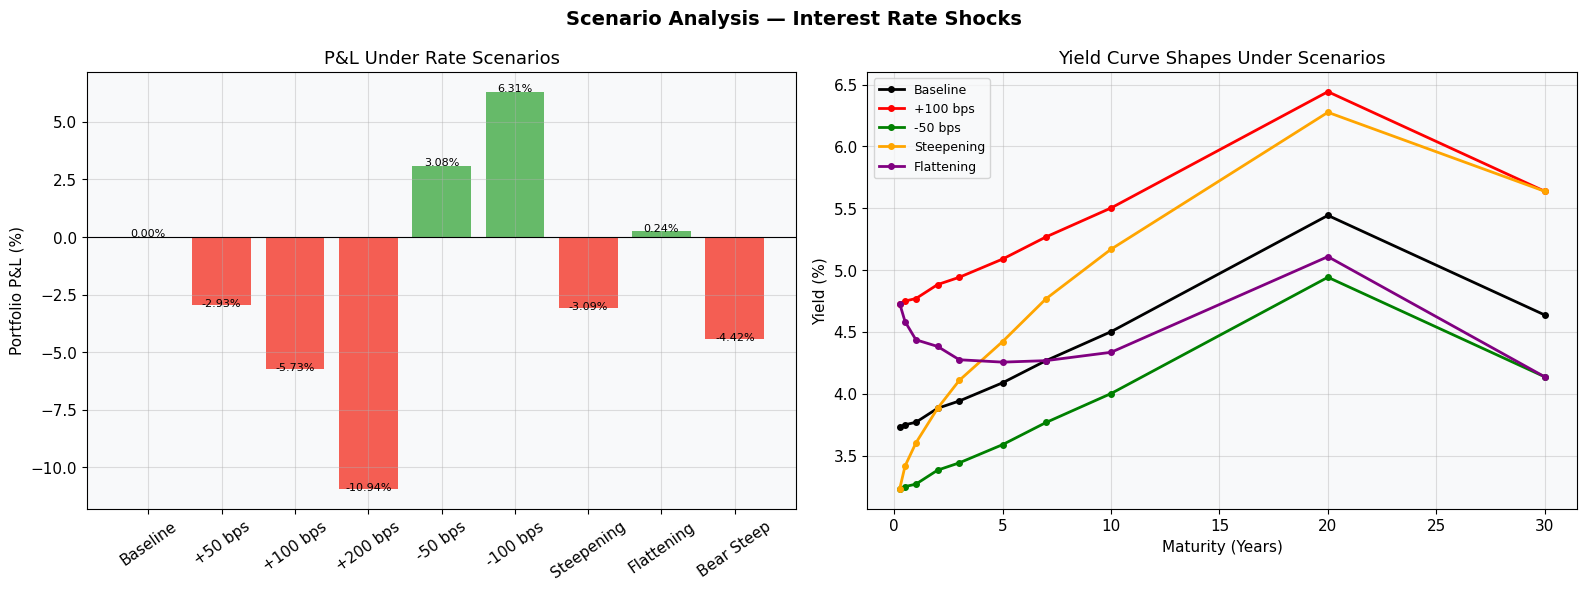

✅  Chart saved: scenario_analysis.png


In [55]:
# ============================================================
# CELL 9 — SCENARIO ANALYSIS (Interest Rate Shocks)
# ============================================================

def shocked_curve(base, bps, shock_type="parallel"):
    n    = len(base)
    s    = bps / 10_000
    bump = np.zeros(n)

    if shock_type == "parallel":
        bump = np.full(n, s)
    elif shock_type == "steepening":   # short ↓, long ↑
        bump = np.linspace(-s/2, s, n)
    elif shock_type == "flattening":   # short ↑, long ↓
        bump = np.linspace(s, -s/2, n)
    elif shock_type == "bear_steep":   # both up, long more
        bump = np.linspace(0.0025, s, n)

    out = base.copy()
    out += pd.Series(bump, index=base.index)
    return out.clip(lower=0.001)


SCENARIOS = [
    ("Baseline",       0,    "parallel"),
    ("+50 bps",       50,    "parallel"),
    ("+100 bps",     100,    "parallel"),
    ("+200 bps",     200,    "parallel"),
    ("-50 bps",      -50,    "parallel"),
    ("-100 bps",    -100,    "parallel"),
    ("Steepening",   100,    "steepening"),
    ("Flattening",   100,    "flattening"),
    ("Bear Steep",   100,    "bear_steep"),
]

rows = []
for name, bps, stype in SCENARIOS:
    curve = CURR_CURVE.copy() if bps == 0 else shocked_curve(CURR_CURVE, bps, stype)
    res   = price_portfolio(BONDS, curve)
    val   = (res["Price"] * res["Weight"]).sum()
    rows.append({"Scenario": name, "Portfolio Value": val})

scen_df = pd.DataFrame(rows)
baseline = scen_df.loc[scen_df["Scenario"] == "Baseline", "Portfolio Value"].iloc[0]
scen_df["P&L"]   = scen_df["Portfolio Value"] - baseline
scen_df["P&L %"] = scen_df["P&L"] / baseline * 100

print("=" * 58)
print("📊  SCENARIO ANALYSIS RESULTS")
print("=" * 58)
print(scen_df.to_string(index=False, float_format="{:.4f}".format))

# ── Plot ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Scenario Analysis — Interest Rate Shocks", fontsize=14, fontweight="bold")

ax = axes[0]
colors_bar = ["#4CAF50" if v >= 0 else "#F44336" for v in scen_df["P&L %"]]
bars = ax.bar(scen_df["Scenario"], scen_df["P&L %"], color=colors_bar, alpha=0.85)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Portfolio P&L (%)")
ax.set_title("P&L Under Rate Scenarios")
ax.tick_params(axis="x", rotation=35)
for bar, v in zip(bars, scen_df["P&L %"]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (0.02 if v >= 0 else -0.07),
            f"{v:.2f}%", ha="center", fontsize=8)

ax2 = axes[1]
plot_scens = [("Baseline",0,"parallel"), ("+100 bps",100,"parallel"),
              ("-50 bps",-50,"parallel"), ("Steepening",100,"steepening"),
              ("Flattening",100,"flattening")]
for (name, bps, st), color in zip(plot_scens, ["black","red","green","orange","purple"]):
    c = CURR_CURVE.copy() if bps == 0 else shocked_curve(CURR_CURVE, bps, st)
    ax2.plot(TENOR_YEARS, c.values*100, marker="o", markersize=4,
             linewidth=2, color=color, label=name)
ax2.set_title("Yield Curve Shapes Under Scenarios")
ax2.set_xlabel("Maturity (Years)")
ax2.set_ylabel("Yield (%)")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig("scenario_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅  Chart saved: scenario_analysis.png")

🔄  Building historical P&L distribution …

📊  HISTORICAL VaR
  VaR  95%  :   -31,391.69  (-2.632%)
  VaR  99%  :   -43,891.71  (-3.680%)
  CVaR 95%  :   -40,396.38  (-3.387%)
  Obs       : 134


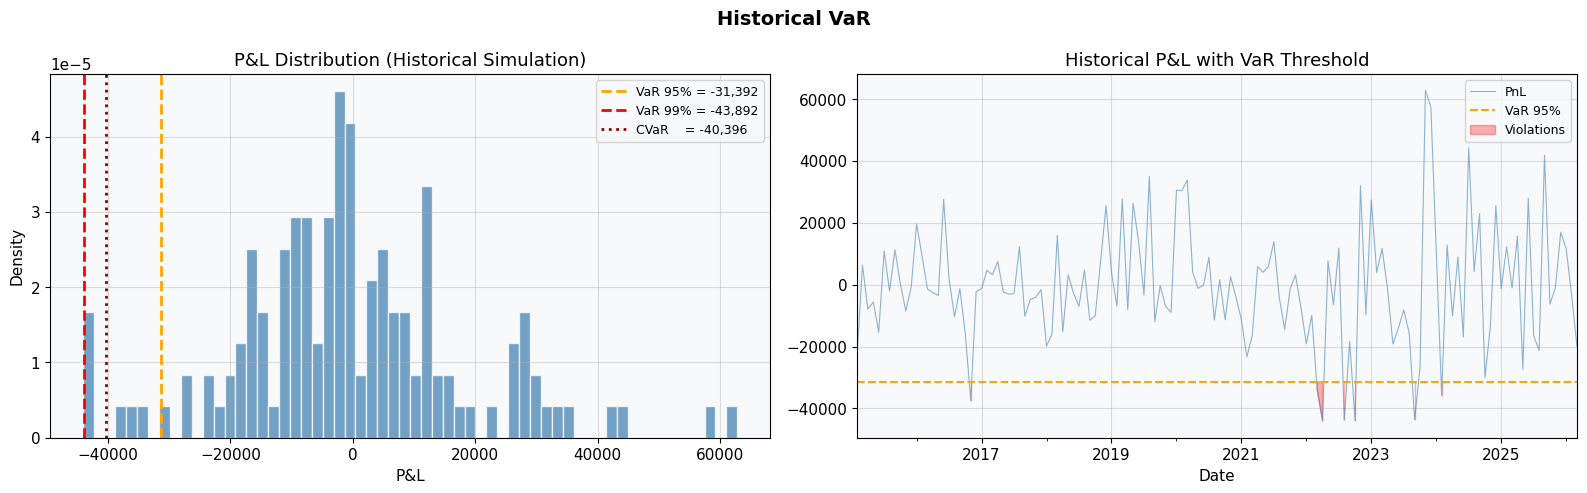

✅  Chart saved: historical_var.png


In [56]:
# ============================================================
# CELL 10 — HISTORICAL VaR
# Apply every observed yield change to current portfolio
# and build an empirical P&L distribution.
# ============================================================

print("🔄  Building historical P&L distribution …")

pnl_hist = []
for date, delta_y in yield_changes.iterrows():
    sc = (CURR_CURVE + delta_y).clip(lower=0.001)
    r  = price_portfolio(BONDS, sc)
    v  = (r["Price"] * r["Weight"]).sum()
    pnl_hist.append({"Date": date, "PnL": v - PTF_VALUE})

PNL_HIST = pd.DataFrame(pnl_hist).set_index("Date")

HIST_VAR95  = np.percentile(PNL_HIST["PnL"], (1-CONFIDENCE)*100)
HIST_VAR99  = np.percentile(PNL_HIST["PnL"], 1)
HIST_CVAR95 = PNL_HIST.loc[PNL_HIST["PnL"] <= HIST_VAR95, "PnL"].mean()

print("\n" + "="*55)
print("📊  HISTORICAL VaR")
print("="*55)
print(f"  VaR  95%  : {HIST_VAR95:>12,.2f}  ({HIST_VAR95/PTF_VALUE*100:.3f}%)")
print(f"  VaR  99%  : {HIST_VAR99:>12,.2f}  ({HIST_VAR99/PTF_VALUE*100:.3f}%)")
print(f"  CVaR 95%  : {HIST_CVAR95:>12,.2f}  ({HIST_CVAR95/PTF_VALUE*100:.3f}%)")
print(f"  Obs       : {len(PNL_HIST):,}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Historical VaR", fontsize=14, fontweight="bold")

ax = axes[0]
ax.hist(PNL_HIST["PnL"], bins=60, color="steelblue", alpha=0.75,
        edgecolor="white", density=True)
ax.axvline(HIST_VAR95,  color="orange",  lw=2, ls="--", label=f"VaR 95% = {HIST_VAR95:,.0f}")
ax.axvline(HIST_VAR99,  color="red",     lw=2, ls="--", label=f"VaR 99% = {HIST_VAR99:,.0f}")
ax.axvline(HIST_CVAR95, color="darkred", lw=2, ls=":",  label=f"CVaR    = {HIST_CVAR95:,.0f}")
ax.set_title("P&L Distribution (Historical Simulation)")
ax.set_xlabel("P&L")
ax.set_ylabel("Density")
ax.legend(fontsize=9)

ax2 = axes[1]
PNL_HIST["PnL"].plot(ax=ax2, color="steelblue", alpha=0.6, lw=0.8)
ax2.axhline(HIST_VAR95, color="orange", lw=1.5, ls="--", label="VaR 95%")
ax2.fill_between(PNL_HIST.index, PNL_HIST["PnL"], HIST_VAR95,
                 where=PNL_HIST["PnL"] < HIST_VAR95,
                 alpha=0.3, color="red", label="Violations")
ax2.set_title("Historical P&L with VaR Threshold")
ax2.set_xlabel("Date")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig("historical_var.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅  Chart saved: historical_var.png")

📊  PARAMETRIC VaR (Delta-Normal + Convexity)
  P&L Mean  :    -1,366.27
  P&L Std   :    17,002.21
  VaR  95%  :   -29,332.43  (-2.459%)
  VaR  99%  :   -40,919.34  (-3.431%)
  CVaR 95%  :   -36,436.96  (-3.055%)

  Jarque-Bera: stat=22.785  p=0.0000
  ⚠️  P&L is NOT normal — parametric VaR may underestimate tail risk!


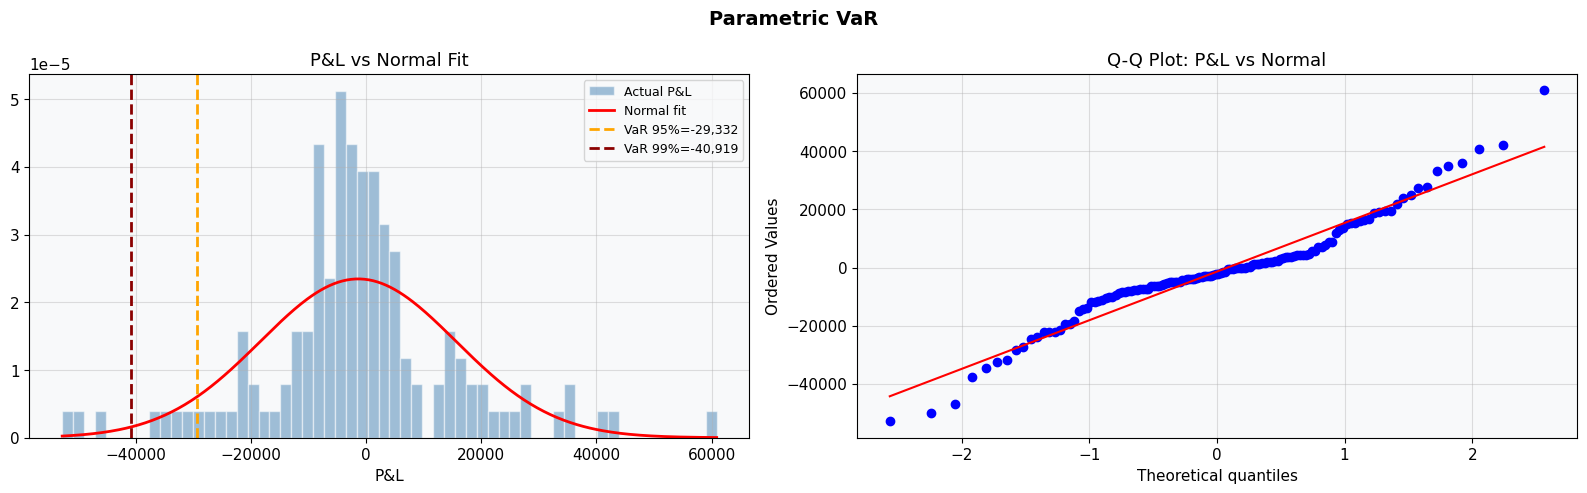

✅  Chart saved: parametric_var.png


In [57]:
# ============================================================
# CELL 11 — PARAMETRIC (Delta-Normal) VaR
# ΔP ≈ (−D_mod·Δy + ½·Conv·Δy²) · P
# where Δy = mean parallel shift across tenors
# ============================================================

parallel_shifts = yield_changes.mean(axis=1)   # mean change across tenors

APPROX_PNL = (-PTF_MOD_DUR * parallel_shifts
              + 0.5 * PTF_CONV * parallel_shifts**2) * PTF_VALUE

mu_p  = APPROX_PNL.mean()
sig_p = APPROX_PNL.std()
z95   = stats.norm.ppf(1 - CONFIDENCE)
z99   = stats.norm.ppf(0.01)

PARAM_VAR95  = mu_p + z95 * sig_p
PARAM_VAR99  = mu_p + z99 * sig_p
PARAM_CVAR95 = mu_p - sig_p * stats.norm.pdf(z95) / (1 - CONFIDENCE)

print("=" * 55)
print("📊  PARAMETRIC VaR (Delta-Normal + Convexity)")
print("=" * 55)
print(f"  P&L Mean  : {mu_p:>12,.2f}")
print(f"  P&L Std   : {sig_p:>12,.2f}")
print(f"  VaR  95%  : {PARAM_VAR95:>12,.2f}  ({PARAM_VAR95/PTF_VALUE*100:.3f}%)")
print(f"  VaR  99%  : {PARAM_VAR99:>12,.2f}  ({PARAM_VAR99/PTF_VALUE*100:.3f}%)")
print(f"  CVaR 95%  : {PARAM_CVAR95:>12,.2f}  ({PARAM_CVAR95/PTF_VALUE*100:.3f}%)")

jb_stat, jb_p = stats.jarque_bera(APPROX_PNL)
print(f"\n  Jarque-Bera: stat={jb_stat:.3f}  p={jb_p:.4f}")
if jb_p < 0.05:
    print("  ⚠️  P&L is NOT normal — parametric VaR may underestimate tail risk!")
else:
    print("  ✅  Normality not rejected at 5% level")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Parametric VaR", fontsize=14, fontweight="bold")

ax = axes[0]
x_r = np.linspace(APPROX_PNL.min(), APPROX_PNL.max(), 300)
ax.hist(APPROX_PNL, bins=60, density=True, alpha=0.5,
        color="steelblue", edgecolor="white", label="Actual P&L")
ax.plot(x_r, stats.norm.pdf(x_r, mu_p, sig_p), "r-", lw=2, label="Normal fit")
ax.axvline(PARAM_VAR95, color="orange",  lw=2, ls="--", label=f"VaR 95%={PARAM_VAR95:,.0f}")
ax.axvline(PARAM_VAR99, color="darkred", lw=2, ls="--", label=f"VaR 99%={PARAM_VAR99:,.0f}")
ax.set_title("P&L vs Normal Fit")
ax.set_xlabel("P&L")
ax.legend(fontsize=9)

ax2 = axes[1]
stats.probplot(APPROX_PNL, dist="norm", plot=ax2)
ax2.set_title("Q-Q Plot: P&L vs Normal")
ax2.get_lines()[1].set_color("red")

plt.tight_layout()
plt.savefig("parametric_var.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅  Chart saved: parametric_var.png")

Running 10,000 PCA-based Monte Carlo simulations ...
Factors used: 4  (97.40% variance)


  MONTE CARLO VaR  (PCA-Based)
  Simulations : 10,000
  VaR  95%    :   -28,520.43  (-2.391%)
  VaR  99%    :   -39,548.47  (-3.316%)
  CVaR 95%    :   -35,339.87  (-2.963%)

  Factor Contribution to Simulated Volatility:
    PC1 Level       : σ =  14,853.11  (62.44% variance)
    PC2 Slope       : σ =   4,576.68  (19.61% variance)
    PC3 Curvature   : σ =   1,298.60  (11.46% variance)
    PC4 Residual    : σ =   6,227.72  (3.88% variance)


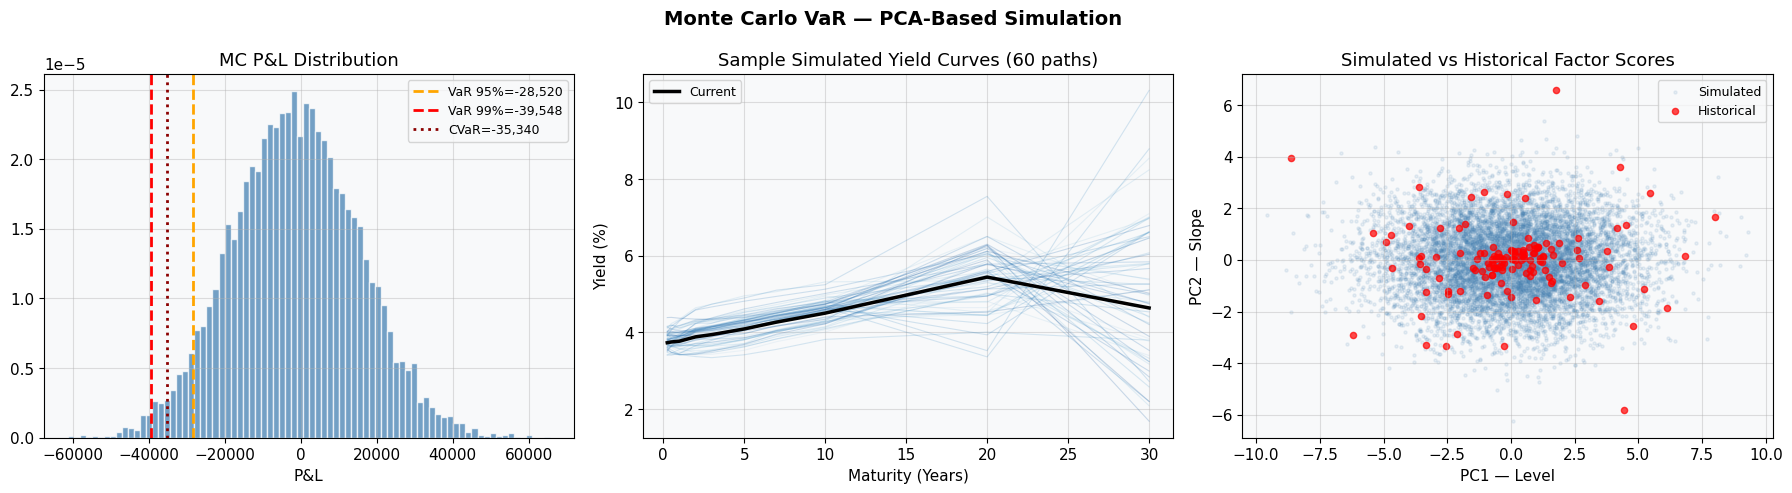

Chart saved: monte_carlo_var.png


In [58]:
# ============================================================
# CELL 12 — MONTE CARLO VaR (PCA-Based Simulation)
# Simulates yield curve moves by drawing from 3 PC factors
# instead of the full 10-tenor covariance matrix.
# PC1=Level, PC2=Slope, PC3=Curvature → covers 98.82% variance.
# ============================================================
np.random.seed(42)
print(f"Running {N_SIMS:,} PCA-based Monte Carlo simulations ...")
print(f"Factors used: {N_FACTORS}  ({pca3.explained_variance_ratio_.sum()*100:.2f}% variance)\n")

# ── Step 1: fit distribution to each factor score ────────────
# Factor scores are already standardised (mean≈0, std≈1 by PCA convention)
# but we use empirical mean/std from actual history to be precise
f_mu  = factor_scores.mean(axis=0)   # shape (3,)
f_std = factor_scores.std(axis=0)    # shape (3,)

# ── Step 2: simulate factor scores ───────────────────────────
# Each factor is simulated independently — they are orthogonal by construction
sim_factors = np.random.normal(
    loc   = f_mu,
    scale = f_std,
    size  = (N_SIMS, N_FACTORS)
)   # shape: (5000, 3)

# ── Step 3: reconstruct yield changes from simulated factors ─
# sim_factors × PC loadings → standardised bps changes (5000 × 10)
sim_scaled_bps = sim_factors @ pca3.components_   # (5000 × 10)

# Unscale: reverse StandardScaler (multiply by std, add mean)
sim_chg_bps = sim_scaled_bps * scaler.scale_ + scaler.mean_  # bps
sim_chg     = sim_chg_bps / 100   # convert bps → decimal

# ── Step 4: compute P&L for each scenario ────────────────────
# Use duration-convexity approximation on the mean parallel shift
mc_pnl = np.empty(N_SIMS)
for i in range(N_SIMS):
    ps = sim_chg[i].mean()   # mean shift across all tenors
    mc_pnl[i] = (-PTF_MOD_DUR * ps + 0.5 * PTF_CONV * ps**2) * PTF_VALUE

# ── Step 5: extract VaR ───────────────────────────────────────
MC_VAR95  = np.percentile(mc_pnl, (1-CONFIDENCE)*100)
MC_VAR99  = np.percentile(mc_pnl, 1)
MC_CVAR95 = mc_pnl[mc_pnl <= MC_VAR95].mean()

print("\n" + "="*55)
print("  MONTE CARLO VaR  (PCA-Based)")
print("="*55)
print(f"  Simulations : {N_SIMS:,}")
print(f"  VaR  95%    : {MC_VAR95:>12,.2f}  ({MC_VAR95/PTF_VALUE*100:.3f}%)")
print(f"  VaR  99%    : {MC_VAR99:>12,.2f}  ({MC_VAR99/PTF_VALUE*100:.3f}%)")
print(f"  CVaR 95%    : {MC_CVAR95:>12,.2f}  ({MC_CVAR95/PTF_VALUE*100:.3f}%)")

# ── Factor contribution breakdown ────────────────────────────
print(f"\n  Factor Contribution to Simulated Volatility:")
factor_labels = ["PC1 Level", "PC2 Slope", "PC3 Curvature", "PC4 Residual"]
for i in range(N_FACTORS):
    # Isolate each factor's contribution by zeroing out the others
    sf_isolated = np.zeros((N_SIMS, N_FACTORS))
    sf_isolated[:, i] = sim_factors[:, i]
    sc_iso = (sf_isolated @ pca3.components_) * scaler.scale_ + scaler.mean_
    pnl_iso = [(-PTF_MOD_DUR * sc_iso[j].mean()/100
                + 0.5 * PTF_CONV * (sc_iso[j].mean()/100)**2)
               * PTF_VALUE for j in range(N_SIMS)]
    vol_iso = np.std(pnl_iso)
    print(f"    {factor_labels[i]:<16}: σ = {vol_iso:>10,.2f}  "
          f"({pca3.explained_variance_ratio_[i]*100:.2f}% variance)")

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Monte Carlo VaR — PCA-Based Simulation",
             fontsize=14, fontweight="bold")

# P&L distribution
ax = axes[0]
ax.hist(mc_pnl, bins=80, color="steelblue", alpha=0.75,
        edgecolor="white", density=True)
ax.axvline(MC_VAR95,  color="orange",  lw=2, ls="--",
           label=f"VaR 95%={MC_VAR95:,.0f}")
ax.axvline(MC_VAR99,  color="red",     lw=2, ls="--",
           label=f"VaR 99%={MC_VAR99:,.0f}")
ax.axvline(MC_CVAR95, color="darkred", lw=2, ls=":",
           label=f"CVaR={MC_CVAR95:,.0f}")
ax.set_title("MC P&L Distribution")
ax.set_xlabel("P&L")
ax.legend(fontsize=9)

# Simulated yield curves (sample paths)
ax2 = axes[1]
sample_idx = np.random.choice(N_SIMS, 60, replace=False)
blues = plt.cm.Blues(np.linspace(0.3, 0.9, 60))
for j, idx in enumerate(sample_idx):
    ax2.plot(TENOR_YEARS,
             (CURR_CURVE.values + sim_chg[idx])*100,
             alpha=0.2, lw=0.8, color=blues[j])
ax2.plot(TENOR_YEARS, CURR_CURVE.values*100, "k-", lw=2.5,
         label="Current")
ax2.set_title("Sample Simulated Yield Curves (60 paths)")
ax2.set_xlabel("Maturity (Years)")
ax2.set_ylabel("Yield (%)")
ax2.legend(fontsize=9)

# Factor score scatter (PC1 vs PC2)
ax3 = axes[2]
ax3.scatter(sim_factors[:,0], sim_factors[:,1],
            alpha=0.1, s=5, color="steelblue", label="Simulated")
ax3.scatter(factor_scores[:,0], factor_scores[:,1],
            alpha=0.7, s=20, color="red", label="Historical")
ax3.set_xlabel("PC1 — Level")
ax3.set_ylabel("PC2 — Slope")
ax3.set_title("Simulated vs Historical Factor Scores")
ax3.legend(fontsize=9)

plt.tight_layout()
plt.savefig("monte_carlo_var.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: monte_carlo_var.png")


In [59]:
# ============================================================
# CELL 13 — VaR BACKTESTING
# ┌──────────────────────────────────────────────────┐
# │  1. Kupiec POF Test       (correct exceedance %) │
# │  2. Christoffersen Test   (violations independent)│
# │  3. Basel Traffic Light   (regulatory zone)       │
# └──────────────────────────────────────────────────┘
# Split: 70% calibration  |  30% out-of-sample test
# ============================================================

# ── Train / Test split ───────────────────────────────────
n_total = len(PNL_HIST)
n_train = int(n_total * 0.70)
train_pnl = PNL_HIST.iloc[:n_train]["PnL"]
test_pnl  = PNL_HIST.iloc[n_train:]["PnL"]
T         = len(test_pnl)

print(f"  Calibration : {train_pnl.index[0].date()} → {train_pnl.index[-1].date()}  ({n_train} obs)")
print(f"  Test        : {test_pnl.index[0].date()} → {test_pnl.index[-1].date()}  ({T} obs)")


# ── Re-calibrate VaR on TRAINING data ────────────────────
def calibrate_var(pnl_series, conf=0.95):
    """Return (hist_var, param_var, mc_var) for a P&L series."""
    # Historical
    h_var = np.percentile(pnl_series, (1-conf)*100)

    # Parametric (normal)
    mu_, sd_ = pnl_series.mean(), pnl_series.std()
    p_var    = mu_ + stats.norm.ppf(1-conf) * sd_

    # Monte Carlo (bootstrap from empirical)
    mc_boot  = np.random.choice(pnl_series.values, size=10_000, replace=True)
    m_var    = np.percentile(mc_boot, (1-conf)*100)

    return h_var, p_var, m_var


H_VAR, P_VAR, M_VAR = calibrate_var(train_pnl, CONFIDENCE)

print(f"\n  Calibrated VaR estimates (on training set):")
print(f"    Historical  : {H_VAR:>10,.2f}")
print(f"    Parametric  : {P_VAR:>10,.2f}")
print(f"    Monte Carlo : {M_VAR:>10,.2f}")


# ── Test Functions ────────────────────────────────────────
def kupiec_test(T, x, conf):
    """
    POF (Proportion of Failures) test.
    H0: true exceedance prob = 1-conf
    LR_pof ~ chi2(1) under H0
    """
    p0  = 1 - conf
    eps = 1e-10
    if x == 0:
        lr = -2 * T * np.log(1 - p0 + eps)
    elif x == T:
        lr = -2 * T * np.log(p0 + eps)
    else:
        px  = x / T
        lr  = -2 * (x*np.log(p0/(px+eps)) + (T-x)*np.log((1-p0)/(1-px+eps)))
    pval   = 1 - stats.chi2.cdf(max(lr, 0), df=1)
    return round(lr, 4), round(pval, 6), pval < 0.05


def christoffersen_test(violations_bool):
    """
    Independence test.  H0: violations are iid.
    LR_ind ~ chi2(1) under H0.
    Rejection (p < 0.05) means violations are CLUSTERED → bad model.
    """
    v = violations_bool.astype(int).values
    n00=n01=n10=n11 = 0
    for i in range(1, len(v)):
        a, b = v[i-1], v[i]
        if   a==0 and b==0: n00+=1
        elif a==0 and b==1: n01+=1
        elif a==1 and b==0: n10+=1
        else:               n11+=1

    denom_01 = n00+n01; denom_11 = n10+n11
    if denom_01==0 or denom_11==0:
        return None, None, False

    p01 = np.clip(n01/denom_01, 1e-10, 1-1e-10)
    p11 = np.clip(n11/denom_11, 1e-10, 1-1e-10)
    p   = np.clip((n01+n11)/(n00+n01+n10+n11), 1e-10, 1-1e-10)

    L_ind = (1-p01)**n00 * p01**n01 * (1-p11)**n10 * p11**n11
    L_dep = (1-p)**(n00+n10) * p**(n01+n11)

    if L_dep < 1e-300 or L_ind < 1e-300:
        return None, None, False

    lr   = -2 * np.log(L_dep / L_ind)
    pval = 1 - stats.chi2.cdf(max(lr,0), df=1)
    return round(lr, 4), round(pval, 6), pval < 0.05


def traffic_light(n_viol, T, conf):
    """Basel 3 Traffic Light scaled to 250-day window."""
    v250 = round(n_viol * 250 / T)
    if v250 <= 4:
        return "🟢 GREEN",  v250, "No capital add-on"
    elif v250 <= 9:
        return "🟡 YELLOW", v250, "Increased capital add-on"
    else:
        return "🔴 RED",    v250, "Model rejected by regulator"


# ── Run backtests ─────────────────────────────────────────
BT_METHODS = {"Historical": H_VAR, "Parametric": P_VAR, "Monte Carlo": M_VAR}
BT_RESULTS = []
VIOL_SERIES = {}

print(f"\n{'='*68}")
print(f"{'Method':<14} {'VaR':>10} {'Violations':>12} {'Exc%':>8} {'Exp%':>8}")
print(f"{'='*68}")

for method, var_est in BT_METHODS.items():
    viols   = test_pnl < var_est
    n_viols = viols.sum()
    exc_pct = n_viols / T * 100
    exp_pct = (1 - CONFIDENCE) * 100

    VIOL_SERIES[method] = viols

    lr_k, pv_k, rej_k   = kupiec_test(T, n_viols, CONFIDENCE)
    lr_c, pv_c, clus_c  = christoffersen_test(viols)
    zone, v250, action   = traffic_light(n_viols, T, CONFIDENCE)

    BT_RESULTS.append({
        "Method": method, "VaR": var_est,
        "Violations": n_viols, "Exc%": exc_pct, "Exp%": exp_pct,
        "Kupiec LR": lr_k, "Kupiec p": pv_k, "Kupiec Reject": rej_k,
        "Christo stat": lr_c, "Christo p": pv_c, "Clustered": clus_c,
        "Traffic Light": zone, "Basel Action": action,
    })
    print(f"{method:<14} {var_est:>10,.2f} {n_viols:>12} {exc_pct:>8.2f}% {exp_pct:>8.2f}%")

print(f"{'='*68}")


# ── Detailed report ───────────────────────────────────────
print("\n📋  DETAILED BACKTEST REPORT\n")
for r in BT_RESULTS:
    k_pass  = "✅ PASS" if not r["Kupiec Reject"] else "❌ FAIL"
    c_pass  = "✅ INDEPENDENT" if not r["Clustered"] else "⚠️  CLUSTERED"
    print(f"  {'─'*58}")
    print(f"  📌 {r['Method']} VaR")
    print(f"  {'─'*58}")
    print(f"  VaR Estimate      : {r['VaR']:>10,.2f}")
    print(f"  Violations        : {r['Violations']:>6} / {T}  ({r['Exc%']:.2f}%  |  expected {r['Exp%']:.2f}%)")
    print(f"  Kupiec POF        : LR={r['Kupiec LR']}  p={r['Kupiec p']}  → {k_pass}")
    print(f"  Christoffersen    : {c_pass}  (p={r['Christo p']})")
    print(f"  Traffic Light     : {r['Traffic Light']}  ({r['Violations']} → {r['Basel Action']})")
    print()

  Calibration : 2015-02-28 → 2022-10-31  (93 obs)
  Test        : 2022-11-30 → 2026-03-31  (41 obs)

  Calibrated VaR estimates (on training set):
    Historical  : -27,535.22
    Parametric  : -27,756.34
    Monte Carlo : -33,858.05

Method                VaR   Violations     Exc%     Exp%
Historical     -27,535.22            3     7.32%     5.00%
Parametric     -27,756.34            3     7.32%     5.00%
Monte Carlo    -33,858.05            2     4.88%     5.00%

📋  DETAILED BACKTEST REPORT

  ──────────────────────────────────────────────────────────
  📌 Historical VaR
  ──────────────────────────────────────────────────────────
  VaR Estimate      : -27,535.22
  Violations        :      3 / 41  (7.32%  |  expected 5.00%)
  Kupiec POF        : LR=0.408  p=0.522988  → ✅ PASS
  Christoffersen    : ✅ INDEPENDENT  (p=0.485259)
  Traffic Light     : 🔴 RED  (3 → Model rejected by regulator)

  ──────────────────────────────────────────────────────────
  📌 Parametric VaR
  ────────────────

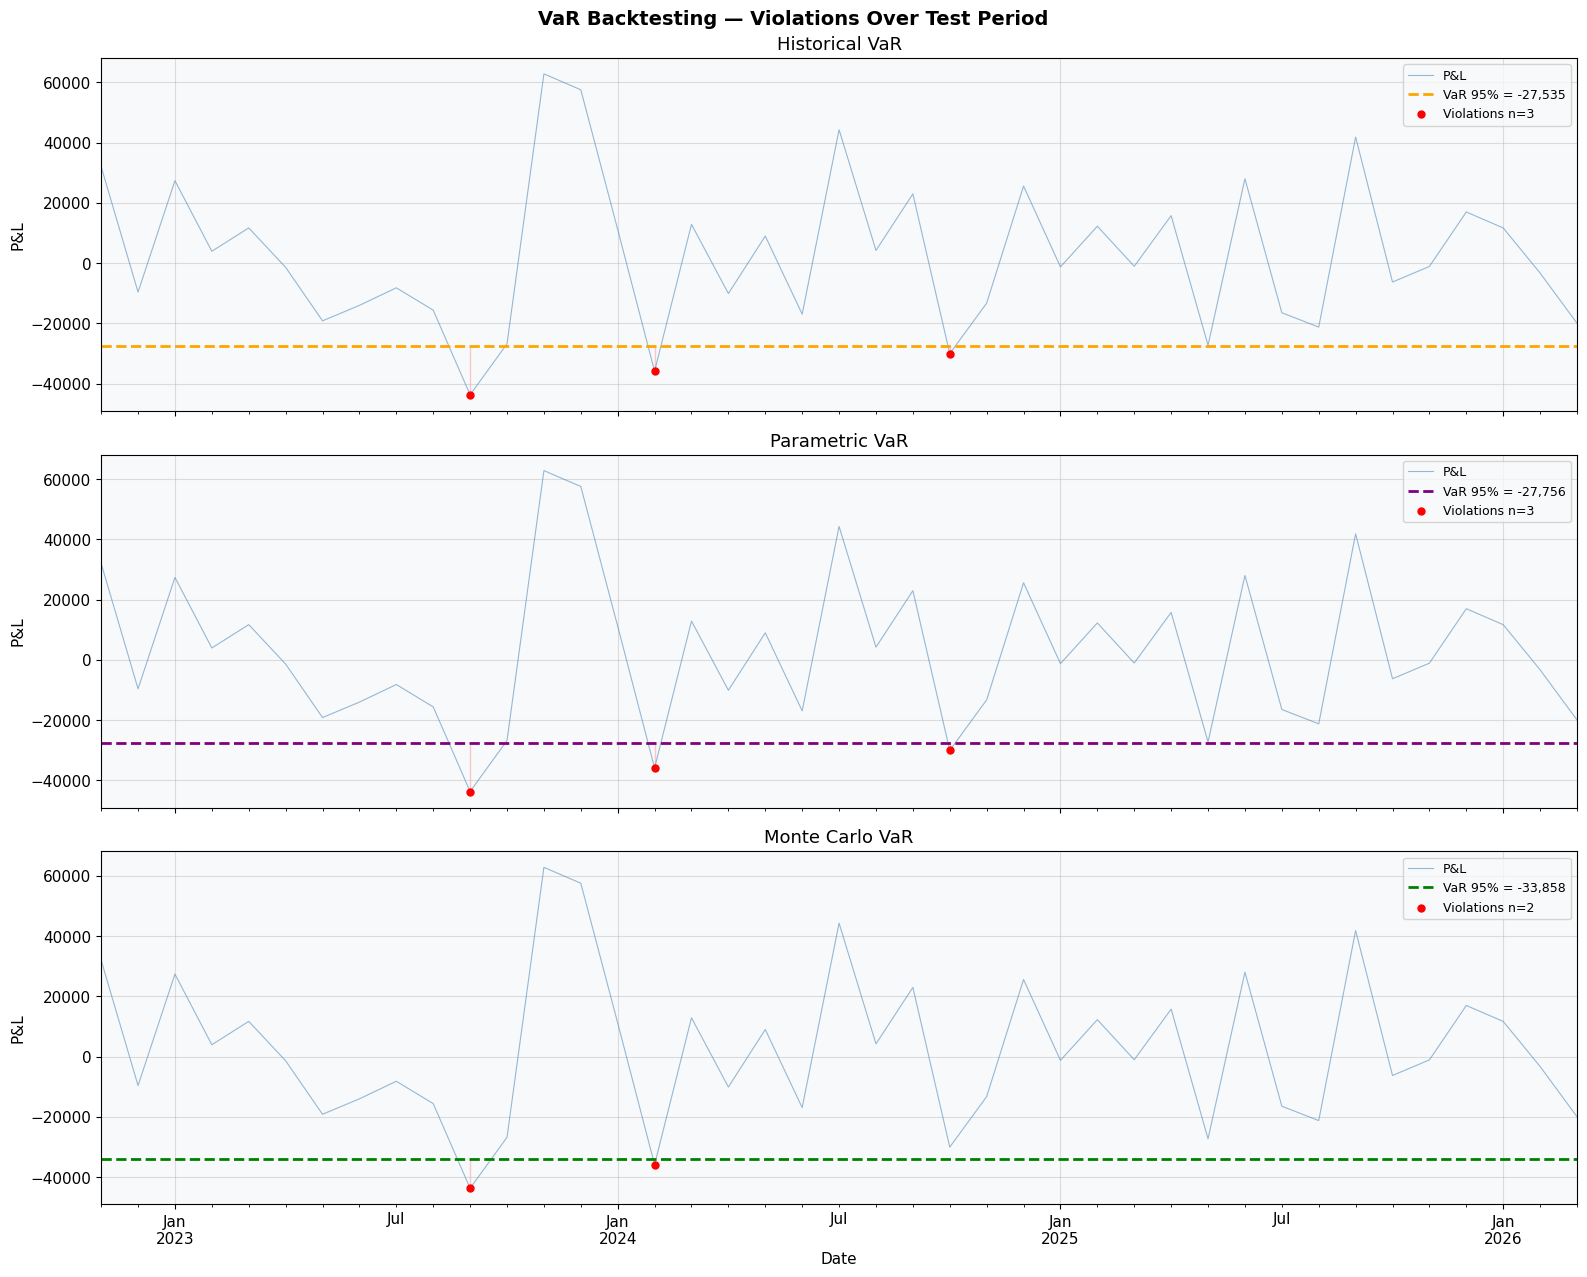

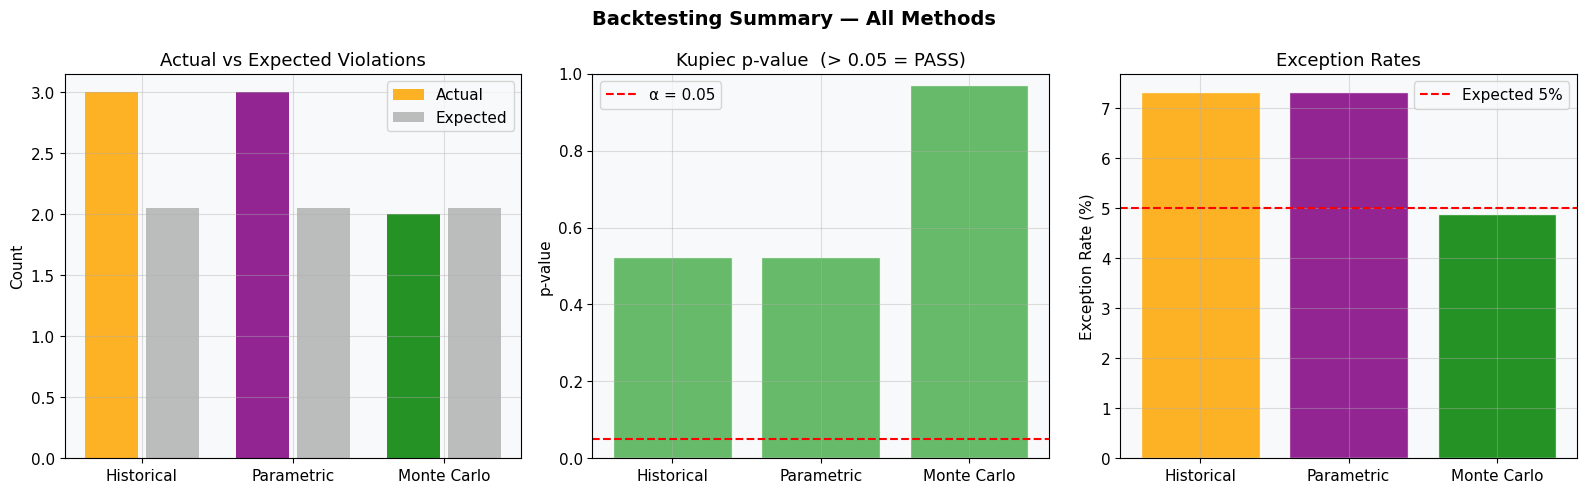

✅  Charts saved: var_backtesting.png  |  backtest_comparison.png


In [60]:
# ============================================================
# CELL 14 — BACKTESTING VISUALISATION
# ============================================================

# ── Panel 1: Violation plots for each method ──────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=True)
fig.suptitle("VaR Backtesting — Violations Over Test Period",
             fontsize=14, fontweight="bold")

method_colors = {"Historical": "orange", "Parametric": "purple", "Monte Carlo": "green"}

for ax, (method, var_est) in zip(axes, BT_METHODS.items()):
    viols = VIOL_SERIES[method]
    test_pnl.plot(ax=ax, color="steelblue", alpha=0.55, lw=0.8, label="P&L")
    ax.axhline(var_est, color=method_colors[method], lw=2, ls="--",
               label=f"VaR 95% = {var_est:,.0f}")
    viol_pnl = test_pnl[viols]
    # Ensure viol_pnl is not empty before attempting to scatter plot
    if not viol_pnl.empty:
        ax.scatter(viol_pnl.index, viol_pnl.values,
                   color="red", s=25, zorder=5, label=f"Violations n={viols.sum()}")
    ax.fill_between(test_pnl.index, test_pnl.values, var_est,
                    where=test_pnl.values < var_est, alpha=0.2, color="red")
    ax.set_title(f"{method} VaR")
    ax.set_ylabel("P&L")
    ax.legend(loc="upper right", fontsize=9)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.savefig("var_backtesting.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Panel 2: Comparison summary ──────────────────────────
bt_df   = pd.DataFrame(BT_RESULTS)
exp_cnt = (1 - CONFIDENCE) * T

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Backtesting Summary — All Methods", fontsize=14, fontweight="bold")
x   = np.arange(len(bt_df))
clr = list(method_colors.values())

ax = axes[0]
ax.bar(x - 0.2, bt_df["Violations"], 0.35, color=clr, alpha=0.85, label="Actual")
ax.bar(x + 0.2, [exp_cnt]*3, 0.35, color="gray", alpha=0.5, label="Expected")
ax.set_xticks(x); ax.set_xticklabels(bt_df["Method"])
ax.set_title("Actual vs Expected Violations")
ax.set_ylabel("Count")
ax.legend()

ax2 = axes[1]
pvs = [r["Kupiec p"] if r["Kupiec p"] is not None else 0 for r in BT_RESULTS]
bar_clr2 = ["#4CAF50" if p >= 0.05 else "#F44336" for p in pvs]
ax2.bar(bt_df["Method"], pvs, color=bar_clr2, alpha=0.85, edgecolor="white")
ax2.axhline(0.05, color="red", ls="--", lw=1.5, label="α = 0.05")
ax2.set_title("Kupiec p-value  (> 0.05 = PASS)")
ax2.set_ylabel("p-value")
ax2.set_ylim(0, 1)
ax2.legend()

ax3 = axes[2]
ax3.bar(bt_df["Method"], bt_df["Exc%"], color=clr, alpha=0.85, edgecolor="white")
ax3.axhline((1-CONFIDENCE)*100, color="red", ls="--", lw=1.5,
            label=f"Expected {(1-CONFIDENCE)*100:.0f}%")
ax3.set_title("Exception Rates")
ax3.set_ylabel("Exception Rate (%)")
ax3.legend()

plt.tight_layout()
plt.savefig("backtest_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅  Charts saved: var_backtesting.png  |  backtest_comparison.png")

In [61]:
# ============================================================
# CELL 15 — FINAL SUMMARY DASHBOARD
# ============================================================

W = 68
print("═"*W)
print("  📊 YIELD CURVE DYNAMICS & BOND PORTFOLIO RISK — FINAL SUMMARY")
print("═"*W)

print(f"\n  DATA")
print(f"  ├── Source       : {DATA_SOURCE}")
print(f"  ├── Period       : {yields_df.index[0].date()} → {yields_df.index[-1].date()}")
print(f"  └── Obs          : {len(yields_df):,} monthly")

print(f"\n  YIELD CURVE (most recent, %)")
for col, val in (CURR_CURVE * 100).items():
    print(f"  │   {col:<5} → {val:.3f}%")

print(f"\n  PORTFOLIO")
print(f"  ├── Bonds        : {len(BONDS)} (2Y, 5Y, 10Y, 20Y)")
print(f"  ├── Value        : {PTF_VALUE:>14,.4f}  {CURRENCY}")
print(f"  ├── Mod Duration : {PTF_MOD_DUR:>14.4f}  years")
print(f"  └── Convexity    : {PTF_CONV:>14.4f}")

print(f"\n  VaR  (95%, 1-period)")
print(f"  {'Method':<14} {'VaR':>14}  {'as % of Portfolio'}")
print(f"  {'─'*50}")
for name, v in [("Historical", HIST_VAR95), ("Parametric", PARAM_VAR95),
                ("Monte Carlo", MC_VAR95)]:
    print(f"  {name:<14} {v:>14,.2f}  {v/PTF_VALUE*100:.3f}%")

print(f"\n  BACKTESTING RESULTS (test window: {T} obs)")
print(f"  {'Method':<14} {'Violations':>12}  {'Kupiec':>9}  {'Traffic Light'}")
print(f"  {'─'*58}")
for r in BT_RESULTS:
    ku = "PASS ✅" if not r["Kupiec Reject"] else "FAIL ❌"
    print(f"  {r['Method']:<14} {r['Violations']:>12}  {ku:>9}  {r['Traffic Light']}")

print(f"\n  KEY INSIGHTS")
print(f"  ├── Yield curve: Level (PC1) explains most variance → parallel shifts dominate")
print(f"  ├── Duration {PTF_MOD_DUR:.2f}Y → 100 bps ↑ ≈ {-PTF_MOD_DUR*0.01*100:.2f}% portfolio loss")
print(f"  ├── Convexity {PTF_CONV:.2f} → non-linear buffer for large rate moves")
print(f"  ├── Longer bonds (10Y, 20Y) drive most of the interest rate risk")
print(f"  └── CVaR > VaR confirms fat left tail → Historical/MC preferred over Parametric")

print(f"\n  SAVED CHARTS")
for f in ["yield_curve_dynamics.png","pca_yield_curve.png","scenario_analysis.png",
          "historical_var.png","parametric_var.png","monte_carlo_var.png",
          "var_backtesting.png","backtest_comparison.png"]:
    print(f"  │   {f}")
print(f"\n{'═'*W}")
print(f"  ✅  Analysis complete!")
print(f"{'═'*W}")

════════════════════════════════════════════════════════════════════
  📊 YIELD CURVE DYNAMICS & BOND PORTFOLIO RISK — FINAL SUMMARY
════════════════════════════════════════════════════════════════════

  DATA
  ├── Source       : US Treasury (home.treasury.gov)
  ├── Period       : 2015-01-31 → 2026-03-31
  └── Obs          : 135 monthly

  YIELD CURVE (most recent, %)
  │   3M    → 3.730%
  │   6M    → 3.750%
  │   1Y    → 3.770%
  │   2Y    → 3.883%
  │   3Y    → 3.942%
  │   5Y    → 4.089%
  │   7Y    → 4.268%
  │   10Y   → 4.502%
  │   20Y   → 5.442%
  │   30Y   → 4.637%

  PORTFOLIO
  ├── Bonds        : 4 (2Y, 5Y, 10Y, 20Y)
  ├── Value        : 1,192,740.8316  USD
  ├── Mod Duration :         5.5779  years
  └── Convexity    :        53.2064

  VaR  (95%, 1-period)
  Method                    VaR  as % of Portfolio
  ──────────────────────────────────────────────────
  Historical         -31,391.69  -2.632%
  Parametric         -29,332.43  -2.459%
  Monte Carlo        -28,520.43  